=== CROSS-VALIDATION SUMMARY ===
MAE               3304.7970
RMSE              3869.6666
sMAPE                0.0582
WAPE                 0.0587
Baseline_MAE      7445.1771
Baseline_RMSE     8179.7939
Baseline_sMAPE       0.1312
Baseline_WAPE        0.1325

=== HOLDOUT COMPARISON ===
           Model       MAE      RMSE  sMAPE   WAPE  Avg_Interval_Width
GradientBoosting 3929.2263 4553.7469 0.0665 0.0669           5784.1163
 Baseline_SARIMA 7123.5091 7875.5827 0.1261 0.1213                 NaN


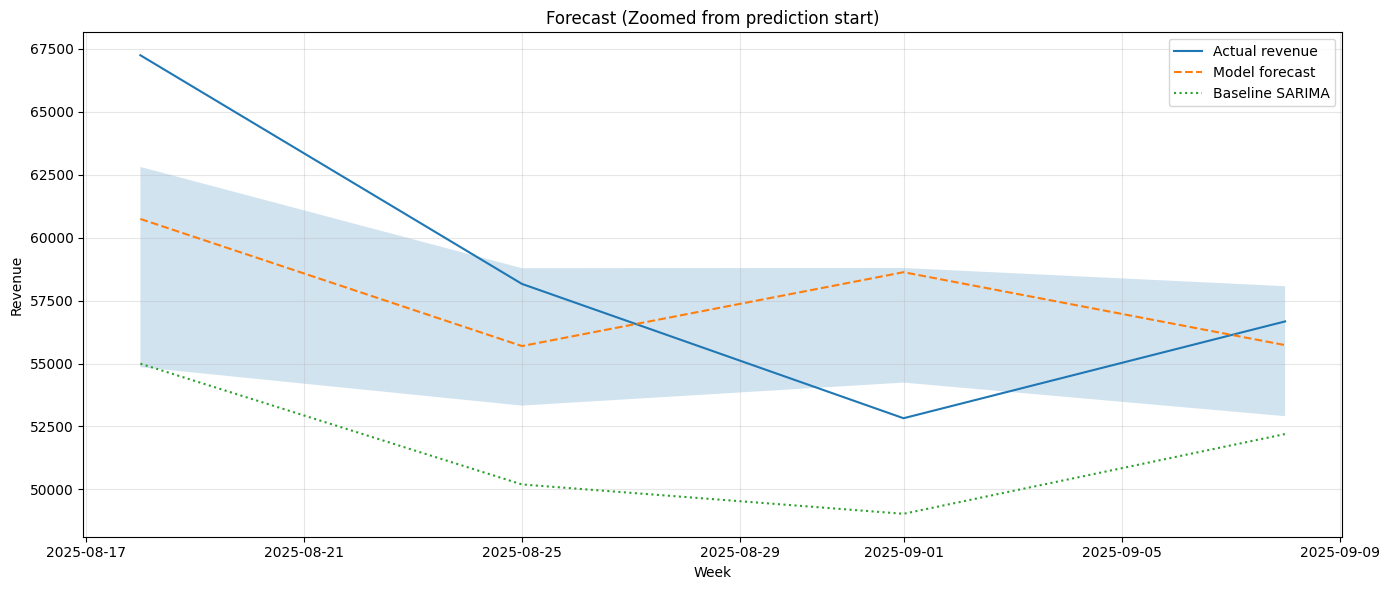

        ds  revenue     pred  baseline_pred
2025-08-18 67249.73 60746.10       54995.16
2025-08-25 58165.01 55695.73       50197.40
2025-09-01 52828.27 58630.40       49031.54
2025-09-08 56675.30 55733.45       52200.18


In [3]:
from dataclasses import dataclass
from typing import Iterable, List, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX


@dataclass
class ForecastConfig:
    data_path: str = "C:/BI/ecommerce_sales_34500.csv"
    target_col: str = "revenue"
    date_col: str = "order_date"
    freq: str = "W-MON"
    horizon: int = 4
    future_periods: int = 8
    initial_train_size: int = 52
    step_size: int = 4
    lag_list: Tuple[int, ...] = (1, 2, 3, 4, 8, 12)
    rolling_windows: Tuple[int, ...] = (4, 8, 12)
    exog_cols: Tuple[str, ...] = (
        "quantity",
        "customers",
        "avg_discount",
        "discount_rate",
        "avg_shipping",
        "return_rate",
        "avg_profit",
        "orders",
        "avg_delivery_days",
    )
    baseline_order: Tuple[int, int, int] = (1, 1, 1)
    baseline_seasonal_order: Tuple[int, int, int, int] = (1, 1, 1, 4)
    random_state: int = 42


def sarima_baseline_forecast(
    train_series: pd.Series,
    steps: int,
    order: Tuple[int, int, int],
    seasonal_order: Tuple[int, int, int, int],
) -> np.ndarray:
    model = SARIMAX(
        train_series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = model.fit(disp=False)
    forecast = fit.forecast(steps=steps)
    return np.asarray(forecast)


def smape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denom = np.where(denom == 0, 1e-8, denom)
    return float(np.mean(np.abs(y_true - y_pred) / denom))


def wape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    denom = np.abs(y_true).sum()
    denom = denom if denom != 0 else 1e-8
    return float(np.abs(y_true - y_pred).sum() / denom)


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def interval_mean_width(lower: np.ndarray, upper: np.ndarray) -> float:
    return float(np.mean(upper - lower))


def load_and_validate_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    required = {
        "order_id", "customer_id", "price", "discount", "quantity", "order_date",
        "returned", "shipping_cost", "profit_margin", "delivery_time_days"
    }
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
    df = df.dropna(subset=["order_date"]).copy()

    numeric_cols = ["price", "discount", "quantity", "shipping_cost", "profit_margin", "delivery_time_days"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["price", "discount", "quantity"]).copy()
    df["discount"] = df["discount"].clip(lower=0, upper=0.95)
    df["quantity"] = df["quantity"].clip(lower=0)

    df["net_price"] = df["price"] * (1 - df["discount"])
    df["revenue"] = df["net_price"] * df["quantity"]
    df["is_discounted"] = (df["discount"] > 0).astype(int)
    df["returned_flag"] = df["returned"].astype(str).str.lower().isin(["yes", "true", "1"]).astype(int)
    return df.sort_values("order_date").reset_index(drop=True)


def aggregate_weekly(df: pd.DataFrame, freq: str) -> pd.DataFrame:
    weekly = (
        df.resample(freq, on="order_date")
        .agg(
            revenue=("revenue", "sum"),
            quantity=("quantity", "sum"),
            customers=("customer_id", "nunique"),
            avg_discount=("discount", "mean"),
            discount_rate=("is_discounted", "mean"),
            avg_shipping=("shipping_cost", "mean"),
            return_rate=("returned_flag", "mean"),
            avg_profit=("profit_margin", "mean"),
            orders=("order_id", "nunique"),
            avg_delivery_days=("delivery_time_days", "mean"),
        )
        .reset_index()
        .rename(columns={"order_date": "ds"})
    )

    weekly = weekly.ffill().bfill()
    if len(weekly) > 1:
        weekly = weekly.iloc[:-1].copy().reset_index(drop=True)
    return weekly


def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["year"] = out["ds"].dt.year
    out["month"] = out["ds"].dt.month
    out["quarter"] = out["ds"].dt.quarter
    out["weekofyear"] = out["ds"].dt.isocalendar().week.astype(int)
    out["week_sin"] = np.sin(2 * np.pi * out["weekofyear"] / 52)
    out["week_cos"] = np.cos(2 * np.pi * out["weekofyear"] / 52)
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    out["trend_idx"] = np.arange(len(out))
    return out


def add_lag_rolling_features(
    df: pd.DataFrame,
    target_col: str,
    lag_list: Iterable[int],
    rolling_windows: Iterable[int],
    exog_cols: Iterable[str],
) -> pd.DataFrame:
    out = df.copy()

    for lag in lag_list:
        out[f"{target_col}_lag_{lag}"] = out[target_col].shift(lag)

    for window in rolling_windows:
        shifted = out[target_col].shift(1)
        out[f"{target_col}_roll_mean_{window}"] = shifted.rolling(window).mean()
        out[f"{target_col}_roll_std_{window}"] = shifted.rolling(window).std()
        out[f"{target_col}_roll_min_{window}"] = shifted.rolling(window).min()
        out[f"{target_col}_roll_max_{window}"] = shifted.rolling(window).max()

    out[f"{target_col}_ewm_4"] = out[target_col].shift(1).ewm(span=4, adjust=False).mean()
    out[f"{target_col}_ewm_8"] = out[target_col].shift(1).ewm(span=8, adjust=False).mean()

    for col in exog_cols:
        out[f"{col}_lag_1"] = out[col].shift(1)
        out[f"{col}_roll_mean_4"] = out[col].shift(1).rolling(4).mean()

    return out


def build_feature_table(weekly: pd.DataFrame, config: ForecastConfig) -> Tuple[pd.DataFrame, List[str]]:
    feat = add_calendar_features(weekly)
    feat = add_lag_rolling_features(
        feat, config.target_col, config.lag_list, config.rolling_windows, config.exog_cols
    )
    feature_cols = [c for c in feat.columns if c not in {"ds", config.target_col}]
    feat = feat.dropna().reset_index(drop=True)
    return feat, feature_cols


def make_time_splits(
    n_obs: int,
    initial_train_size: int,
    horizon: int,
    step_size: int
) -> List[Tuple[np.ndarray, np.ndarray]]:
    splits = []
    train_end = initial_train_size

    while train_end + horizon <= n_obs:
        train_idx = np.arange(0, train_end)
        test_idx = np.arange(train_end, train_end + horizon)
        splits.append((train_idx, test_idx))
        train_end += step_size

    return splits


def fit_quantile_models(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    random_state: int
):
    point_model = GradientBoostingRegressor(
        loss="squared_error",
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        min_samples_leaf=3,
        subsample=0.9,
        random_state=random_state,
    )
    lower_model = GradientBoostingRegressor(
        loss="quantile",
        alpha=0.10,
        n_estimators=400,
        learning_rate=0.03,
        max_depth=3,
        min_samples_leaf=3,
        subsample=0.9,
        random_state=random_state,
    )
    upper_model = GradientBoostingRegressor(
        loss="quantile",
        alpha=0.90,
        n_estimators=400,
        learning_rate=0.03,
        max_depth=3,
        min_samples_leaf=3,
        subsample=0.9,
        random_state=random_state,
    )

    point_model.fit(X_train, y_train)
    lower_model.fit(X_train, y_train)
    upper_model.fit(X_train, y_train)
    return point_model, lower_model, upper_model


def backtest_pipeline(
    feature_df: pd.DataFrame,
    feature_cols: List[str],
    config: ForecastConfig
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    splits = make_time_splits(
        len(feature_df),
        config.initial_train_size,
        config.horizon,
        config.step_size
    )
    if not splits:
        raise ValueError("Not enough weekly observations for the configured backtest.")

    fold_metrics = []
    predictions = []

    for fold, (train_idx, test_idx) in enumerate(splits, start=1):
        train_df = feature_df.iloc[train_idx].copy()
        test_df = feature_df.iloc[test_idx].copy()

        X_train, y_train = train_df[feature_cols], train_df[config.target_col]
        X_test, y_test = test_df[feature_cols], test_df[config.target_col]

        point_model, lower_model, upper_model = fit_quantile_models(X_train, y_train, config.random_state)

        pred = point_model.predict(X_test)
        pred_lower = lower_model.predict(X_test)
        pred_upper = upper_model.predict(X_test)
        baseline_pred = sarima_baseline_forecast(
            train_series=train_df[config.target_col],
            steps=len(test_df),
            order=config.baseline_order,
            seasonal_order=config.baseline_seasonal_order,
        )

        fold_metrics.append({
            "fold": fold,
            "MAE": mean_absolute_error(y_test, pred),
            "RMSE": rmse(y_test, pred),
            "sMAPE": smape(y_test.values, pred),
            "WAPE": wape(y_test.values, pred),
            "Baseline_MAE": mean_absolute_error(y_test, baseline_pred),
            "Baseline_RMSE": rmse(y_test.values, baseline_pred),
            "Baseline_sMAPE": smape(y_test.values, baseline_pred),
            "Baseline_WAPE": wape(y_test.values, baseline_pred),
            "Avg_Interval_Width": interval_mean_width(pred_lower, pred_upper),
        })

        fold_pred = test_df[["ds", config.target_col]].copy()
        fold_pred["pred"] = pred
        fold_pred["pred_lower_80"] = pred_lower
        fold_pred["pred_upper_80"] = pred_upper
        fold_pred["baseline_pred"] = baseline_pred
        fold_pred["fold"] = fold
        predictions.append(fold_pred)

    return pd.DataFrame(fold_metrics), pd.concat(predictions, ignore_index=True)


def fit_final_models(feature_df: pd.DataFrame, feature_cols: List[str], config: ForecastConfig):
    train_df = feature_df.iloc[:-config.horizon].copy()
    holdout_df = feature_df.iloc[-config.horizon:].copy()

    point_model, lower_model, upper_model = fit_quantile_models(
        train_df[feature_cols], train_df[config.target_col], config.random_state
    )

    holdout_pred = holdout_df[["ds", config.target_col]].copy()
    holdout_pred["pred"] = point_model.predict(holdout_df[feature_cols])
    holdout_pred["pred_lower_80"] = lower_model.predict(holdout_df[feature_cols])
    holdout_pred["pred_upper_80"] = upper_model.predict(holdout_df[feature_cols])

    holdout_pred["baseline_pred"] = sarima_baseline_forecast(
        train_series=train_df[config.target_col],
        steps=len(holdout_df),
        order=config.baseline_order,
        seasonal_order=config.baseline_seasonal_order,
    )

    holdout_metrics = pd.DataFrame([{
        "Model": "GradientBoosting",
        "MAE": mean_absolute_error(holdout_df[config.target_col], holdout_pred["pred"]),
        "RMSE": rmse(holdout_df[config.target_col].values, holdout_pred["pred"].values),
        "sMAPE": smape(holdout_df[config.target_col].values, holdout_pred["pred"].values),
        "WAPE": wape(holdout_df[config.target_col].values, holdout_pred["pred"].values),
        "Avg_Interval_Width": interval_mean_width(
            holdout_pred["pred_lower_80"].values,
            holdout_pred["pred_upper_80"].values,
        ),
    }, {
        
    "Model": "Baseline_SARIMA",
    "MAE": mean_absolute_error(holdout_df[config.target_col], holdout_pred["baseline_pred"]),
    "RMSE": rmse(holdout_df[config.target_col].values, holdout_pred["baseline_pred"].values),
    "sMAPE": smape(holdout_df[config.target_col].values, holdout_pred["baseline_pred"].values),
    "WAPE": wape(holdout_df[config.target_col].values, holdout_pred["baseline_pred"].values),
    "Avg_Interval_Width": np.nan,
    }])

    return train_df, holdout_df, holdout_pred, holdout_metrics, point_model, lower_model, upper_model


def recursive_future_forecast(
    raw_weekly: pd.DataFrame,
    point_model,
    lower_model,
    upper_model,
    feature_cols: List[str],
    config: ForecastConfig
) -> pd.DataFrame:
    history = raw_weekly.copy().reset_index(drop=True)
    future_rows = []

    exog_fill_values = {
        col: float(history[col].tail(4).mean()) for col in config.exog_cols
    }

    for step in range(1, config.future_periods + 1):
        next_ds = history["ds"].max() + pd.offsets.Week(weekday=0)
        next_row = {"ds": next_ds}

        for col in config.exog_cols:
            next_row[col] = exog_fill_values[col]

        next_row[config.target_col] = np.nan

        temp = pd.concat([history, pd.DataFrame([next_row])], ignore_index=True)
        temp = add_calendar_features(temp)
        temp = add_lag_rolling_features(
            temp, config.target_col, config.lag_list, config.rolling_windows, config.exog_cols
        )

        row_features = temp.iloc[[-1]][feature_cols].copy()
        pred = float(point_model.predict(row_features)[0])
        pred_lower = float(lower_model.predict(row_features)[0])
        pred_upper = float(upper_model.predict(row_features)[0])

        next_row[config.target_col] = pred
        history = pd.concat([history, pd.DataFrame([next_row])], ignore_index=True)

        future_rows.append({
            "ds": next_ds,
            "forecast": pred,
            "forecast_lower_80": pred_lower,
            "forecast_upper_80": pred_upper,
            "step": step,
        })

    return pd.DataFrame(future_rows)


def plot_results(weekly: pd.DataFrame, holdout_pred: pd.DataFrame, future_fc: pd.DataFrame) -> None:
    plt.figure(figsize=(14, 6))

    # Chỉ lấy đoạn từ lúc bắt đầu dự báo
    start_date = holdout_pred["ds"].min()
    weekly_zoom = weekly[weekly["ds"] >= start_date]

    # Actual (chỉ phần cần thiết)
    plt.plot(weekly_zoom["ds"], weekly_zoom["revenue"], label="Actual revenue")

    # Model forecast
    plt.plot(holdout_pred["ds"], holdout_pred["pred"], linestyle="--", label="Model forecast")

    # Baseline
    plt.plot(holdout_pred["ds"], holdout_pred["baseline_pred"], linestyle=":", label="Baseline SARIMA")

    # Interval
    plt.fill_between(
        holdout_pred["ds"],
        holdout_pred["pred_lower_80"],
        holdout_pred["pred_upper_80"],
        alpha=0.2
    )

    plt.title("Forecast (Zoomed from prediction start)")
    plt.xlabel("Week")
    plt.ylabel("Revenue")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def main() -> Dict[str, pd.DataFrame]:
    config = ForecastConfig()

    raw = load_and_validate_data(config.data_path)
    weekly = aggregate_weekly(raw, config.freq)
    feature_df, feature_cols = build_feature_table(weekly, config)

    cv_metrics, cv_preds = backtest_pipeline(feature_df, feature_cols, config)

    train_df, holdout_df, holdout_pred, holdout_metrics, point_model, lower_model, upper_model = fit_final_models(
        feature_df, feature_cols, config
    )

    future_fc = recursive_future_forecast(
        weekly, point_model, lower_model, upper_model, feature_cols, config
    )

    print("=== CROSS-VALIDATION SUMMARY ===")
    print(cv_metrics[[
        "MAE", "RMSE", "sMAPE", "WAPE",
        "Baseline_MAE", "Baseline_RMSE", "Baseline_sMAPE", "Baseline_WAPE"
    ]].mean().round(4).to_string())

    print("\n=== HOLDOUT COMPARISON ===")
    print(holdout_metrics.round(4).to_string(index=False))

    plot_results(weekly, holdout_pred, future_fc)

    return {
        "weekly": weekly,
        "feature_df": feature_df,
        "cv_metrics": cv_metrics,
        "cv_predictions": cv_preds,
        "holdout_predictions": holdout_pred,
        "holdout_metrics": holdout_metrics,
        "future_forecast": future_fc,
    }


if __name__ == "__main__":
    results = main()
    
holdout_pred = results["holdout_predictions"]

print(holdout_pred[[
    "ds",
    "revenue",
    "pred",
    "baseline_pred"
]].round(2).to_string(index=False))